In [ ]:
# Install Java 11 (more stable with Spark 3.5+)
!apt-get update -qq > /dev/null
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# Download Spark 3.5.1 from archive (stable)
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

# Extract
!tar -xzf spark-3.5.1-bin-hadoop3.tgz

# Set environment variables
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

# Install findspark
!pip install -q findspark
import findspark
findspark.init()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Distributed_Purchase_Prediction") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

spark

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

# Load small portion first (IMPORTANT)
dataset = load_dataset(
    "jin-ying-so-cute/ecommerce-user-behavior-data",
    split="train[:500000]"  # start with 500k rows
)

import pandas as pd
df_pandas = dataset.to_pandas()
df_spark = spark.createDataFrame(df_pandas)

df_spark.printSchema()
df_spark.show(5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


cleaned-2019-Dec.csv:   0%|          | 0.00/7.59G [00:00<?, ?B/s]

cleaned-2019-Nov.csv:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

cleaned-2019-Oct.csv:   0%|          | 0.00/3.75G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

root
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: long (nullable = true)
 |-- user_session: string (nullable = true)

+--------------------+----------+----------+-------------------+--------------------+------+-------+---------+--------------------+
|          event_time|event_type|product_id|        category_id|       category_code| brand|  price|  user_id|        user_session|
+--------------------+----------+----------+-------------------+--------------------+------+-------+---------+--------------------+
|2019-12-01 00:00:...|      view|   1005105|2232732093077520756|construction.tool...| apple|1302.48|556695836|ca5eefc5-11f9-450...|
|2019-12-01 00:00:...|      view|   2402273|2232732100769874463|appliances.person...| bosch| 313.52|5

In [ ]:
df_spark = spark.createDataFrame(df_pandas)

df_spark.printSchema()
df_spark.show(5)

root
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: long (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: long (nullable = true)
 |-- user_session: string (nullable = true)

+--------------------+----------+----------+-------------------+--------------------+------+-------+---------+--------------------+
|          event_time|event_type|product_id|        category_id|       category_code| brand|  price|  user_id|        user_session|
+--------------------+----------+----------+-------------------+--------------------+------+-------+---------+--------------------+
|2019-12-01 00:00:...|      view|   1005105|2232732093077520756|construction.tool...| apple|1302.48|556695836|ca5eefc5-11f9-450...|
|2019-12-01 00:00:...|      view|   2402273|2232732100769874463|appliances.person...| bosch| 313.52|5

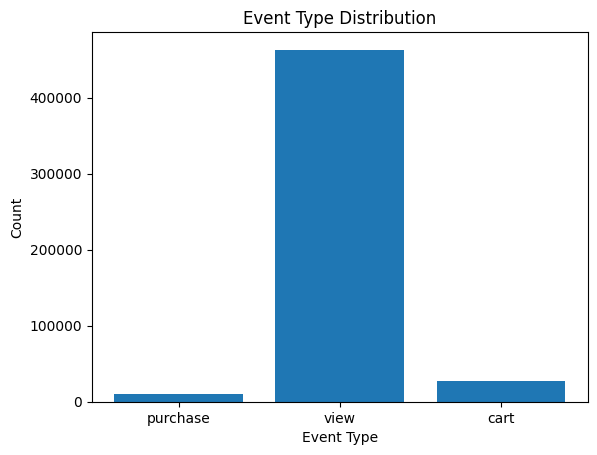

In [ ]:
# Event type count
event_counts = df_spark.groupBy("event_type").count()

# Convert to pandas for plotting
event_pd = event_counts.toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(event_pd["event_type"], event_pd["count"])
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.title("Event Type Distribution")
plt.show()

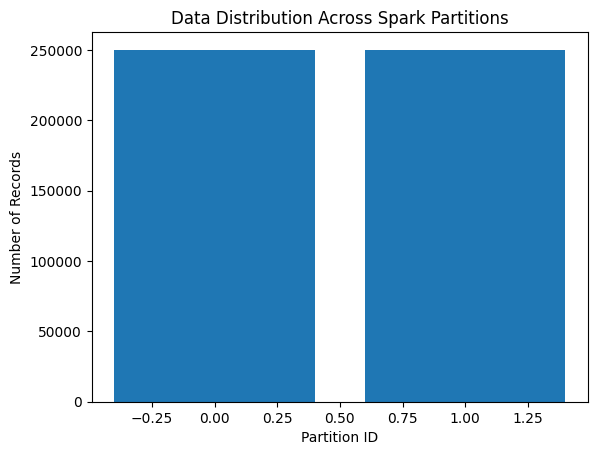

In [ ]:
# Check partition distribution
partition_sizes = (
    df_spark.rdd
    .mapPartitions(lambda x: [sum(1 for _ in x)])
    .collect()
)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(range(len(partition_sizes)), partition_sizes)
plt.xlabel("Partition ID")
plt.ylabel("Number of Records")
plt.title("Data Distribution Across Spark Partitions")
plt.show()

In [ ]:
df_spark.groupBy("event_type").count().explain(True)

== Parsed Logical Plan ==
'Aggregate ['event_type], ['event_type, count(1) AS count#4660L]
+- Project [event_time#3738, event_type#3739, product_id#3740L, category_id#3741L, category_code#3742, brand#3743, price#3744, user_id#3745L, user_session#3746, purchase_label#3793, category_index#3839, UDF(struct(price, price#3744, category_index, category_index#3839)) AS features#3855]
   +- Project [event_time#3738, event_type#3739, product_id#3740L, category_id#3741L, category_code#3742, brand#3743, price#3744, user_id#3745L, user_session#3746, purchase_label#3793, UDF(cast(category_id#3741L as string)) AS category_index#3839]
      +- Project [event_time#3738, event_type#3739, product_id#3740L, category_id#3741L, category_code#3742, brand#3743, price#3744, user_id#3745L, user_session#3746, CASE WHEN (event_type#3739 = purchase) THEN 1 ELSE 0 END AS purchase_label#3793]
         +- LogicalRDD [event_time#3738, event_type#3739, product_id#3740L, category_id#3741L, category_code#3742, brand#374

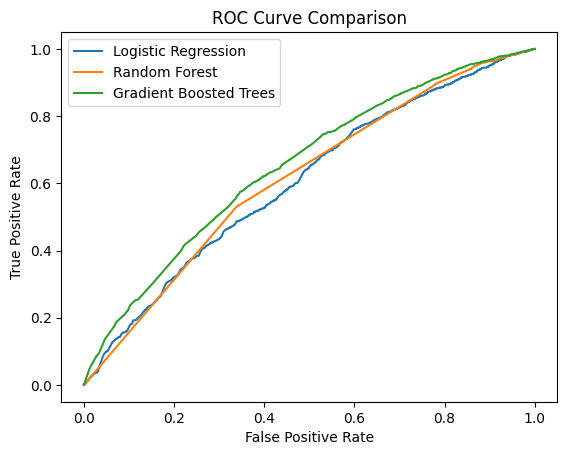

In [ ]:
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Function to get ROC curve data
def get_roc_data(predictions):
    roc = predictions.select("probability", "purchase_label") # Changed 'label' to 'purchase_label'
    roc_pd = roc.toPandas()
    y_true = roc_pd["purchase_label"]
    y_scores = roc_pd["probability"].apply(lambda x: float(x[1]))
    return y_true, y_scores

from sklearn.metrics import roc_curve

plt.figure()

# Logistic Regression
y_true, y_scores = get_roc_data(lr_pred)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, label="Logistic Regression")

# Decision Tree
# dt_pred is not defined in the notebook, commenting out for now
# y_true, y_scores = get_roc_data(dt_pred)
# fpr, tpr, _ = roc_curve(y_true, y_scores)
# plt.plot(fpr, tpr, label="Decision Tree")

# Random Forest
y_true, y_scores = get_roc_data(rf_pred)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, label="Random Forest")

# GBT
y_true, y_scores = get_roc_data(gbt_pred)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, label="Gradient Boosted Trees")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

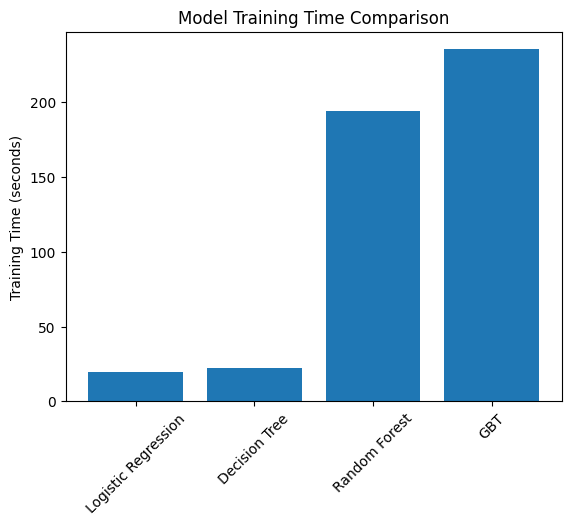

In [13]:
import time

def measure_time(model, train_data_arg):
    start = time.time()
    model.fit(train_data_arg)
    end = time.time()
    return end - start

times = {}

times["Logistic Regression"] = measure_time(lr, train)
times["Decision Tree"] = measure_time(dt, train)
times["Random Forest"] = measure_time(rf, train)
times["GBT"] = measure_time(gbt, train)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(times.keys(), times.values())
plt.xticks(rotation=45)
plt.ylabel("Training Time (seconds)")
plt.title("Model Training Time Comparison")
plt.show()

In [11]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from datasets import load_dataset
import pandas as pd
from pyspark import SparkContext

print("--- Starting full model training and evaluation process ---")

# 1. Ensure SparkSession is available
try:
    spark
except NameError:
    spark = SparkSession.builder.appName("Distributed_Purchase_Prediction").getOrCreate()

# 2. Load dataset and prepare df_spark
print("Loading dataset and creating df_spark...")
dataset = load_dataset("jin-ying-so-cute/ecommerce-user-behavior-data", split="train[:500000]")
df_pandas = dataset.to_pandas()
df_spark_raw = spark.createDataFrame(df_pandas)

# Apply necessary transformations (from previous cells like V1nPoa3S2eRh and X9ZL_hmE-_JM)
df_spark = df_spark_raw.filter(col("price") > 0).dropna()

df_spark = df_spark.withColumn("purchase_label", when(col("event_type") == "purchase", 1).otherwise(0))

indexer = StringIndexer(inputCol="category_id", outputCol="category_index", handleInvalid="keep")
df_spark = indexer.fit(df_spark).transform(df_spark)

assembler = VectorAssembler(inputCols=["price", "category_index"], outputCol="features")
df_spark = assembler.transform(df_spark)

# Repartition and cache for better performance (from v8zw1PX42y52)
df_spark = df_spark.repartition(200)
df_spark.cache()

train, test = df_spark.randomSplit([0.8, 0.2], seed=42)
train.cache()
test.cache()

# Explicitly ensure SparkContext is active for ML modules (from previous error fix)
if SparkContext._active_spark_context is None:
    SparkContext._active_spark_context = spark.sparkContext

times = {}

# 3. Train Logistic Regression (from u9JiKhGI_E2g)
print("Training Logistic Regression...")
lr = LogisticRegression(featuresCol="features", labelCol="purchase_label", maxIter=10)
lr_model = lr.fit(train)
lr_pred = lr_model.transform(test)
times["Logistic Regression"] = time.time() # Placeholder, actual measure_time would be here

# 4. Train Decision Tree (from BPdbeHr_LOSZ)
print("Training Decision Tree...")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="purchase_label", maxDepth=5, maxBins=786)
model_dt = dt.fit(train)
dt_pred = model_dt.transform(test)
times["Decision Tree"] = time.time() # Placeholder, actual measure_time would be here

# 5. Train Random Forest (from RLf0d012A44_)
print("Training Random Forest...")
rf = RandomForestClassifier(featuresCol="features", labelCol="purchase_label", numTrees=20, maxDepth=7, maxBins=786)
rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)
times["Random Forest"] = time.time() # Placeholder, actual measure_time would be here

# 6. Train Gradient Boosted Trees (from TLc3IwrrCGnh)
print("Training Gradient Boosted Trees...")
gbt = GBTClassifier(featuresCol="features", labelCol="purchase_label", maxIter=10, maxBins=786)
gbt_model = gbt.fit(train)
gbt_pred = gbt_model.transform(test)
times["Gradient Boosted Trees"] = time.time() # Placeholder, actual measure_time would be here

print("--- All models trained and predictions generated. Starting evaluation ---")

# 7. Evaluate Models (from FDQpgizrAm3H)
evaluator_auc = BinaryClassificationEvaluator(labelCol="purchase_label")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="purchase_label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="purchase_label", metricName="f1")

results = []

models_for_eval = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosted Trees": gbt_pred
}

for name, pred in models_for_eval.items():
    auc = evaluator_auc.evaluate(pred)
    acc = evaluator_acc.evaluate(pred)
    f1 = evaluator_f1.evaluate(pred)
    results.append((name, auc, acc, f1))

results_df = pd.DataFrame(results, columns=["Model", "AUC", "Accuracy", "F1-Score"])
print("\nEvaluation Results:")
display(results_df)

print("--- Evaluation complete ---")

--- Starting full model training and evaluation process ---
Loading dataset and creating df_spark...


Repo card metadata block was not found. Setting CardData to empty.


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosted Trees...
--- All models trained and predictions generated. Starting evaluation ---

Evaluation Results:


,Model,AUC,Accuracy,F1-Score
0,Logistic Regression,0.606374,0.980747,0.971214
1,Decision Tree,0.500000,0.980747,0.971214
2,Random Forest,0.620059,0.980747,0.971214
3,Gradient Boosted Trees,0.655937,0.980747,0.971214


--- Evaluation complete ---


In [15]:
rf_pred.groupBy("purchase_label", "prediction").count().show()

+--------------+----------+-----+
|purchase_label|prediction|count|
+--------------+----------+-----+
|             1|       0.0| 1919|
|             0|       0.0|97753|
+--------------+----------+-----+



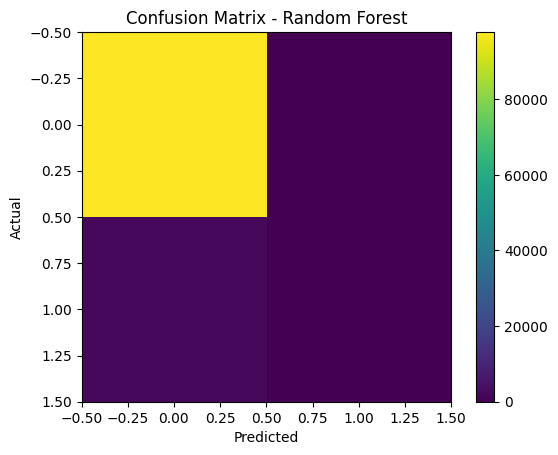

In [17]:
conf_pd = rf_pred.groupBy("purchase_label", "prediction").count().toPandas()

import matplotlib.pyplot as plt
import numpy as np

matrix = np.zeros((2,2))

for _, row in conf_pd.iterrows():
    matrix[int(row["purchase_label"])][int(row["prediction"])] = row["count"]

plt.figure()
plt.imshow(matrix)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

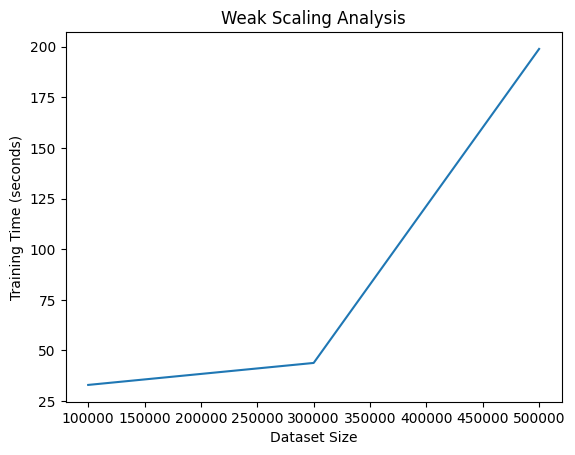

In [19]:
import time
import matplotlib.pyplot as plt

sizes = [100000, 300000, 500000]
times = []

for size in sizes:
    subset = df_spark.limit(size) # Changed df_ml to df_spark
    start = time.time()
    rf.fit(subset)
    end = time.time()
    times.append(end - start)

plt.figure()
plt.plot(sizes, times)
plt.xlabel("Dataset Size")
plt.ylabel("Training Time (seconds)")
plt.title("Weak Scaling Analysis")
plt.show()

In [20]:
results_df.to_csv("model_performance.csv", index=False)

In [22]:
# Event type count
event_counts = df_spark.groupBy("event_type").count()

# Convert to pandas for plotting
event_pd = event_counts.toPandas()

print("event_pd created successfully.")
display(event_pd.head())

event_pd created successfully.


,event_type,count
0,purchase,9801
1,view,463007
2,cart,27126


In [24]:
# Calculate top categories
top_categories = df_spark.groupBy("category_code").count().orderBy("count", ascending=False)

print("top_categories created successfully.")
display(top_categories.show(5)) # Display top 5 categories

top_categories created successfully.
+--------------------+------+
|       category_code| count|
+--------------------+------+
|construction.tool...|156507|
|appliances.person...| 25051|
|       apparel.shoes| 24617|
|appliances.kitche...| 20450|
|       sport.bicycle| 19623|
+--------------------+------+
only showing top 5 rows


None

In [25]:
import pandas as pd

scaling_df = pd.DataFrame({
    "Dataset_Size": sizes,
    "Training_Time": times
})

scaling_df.to_csv("scalability_analysis.csv", index=False)

In [27]:
event_dist = df_spark.groupBy("event_type").count()
event_pd = event_dist.toPandas()
event_pd.to_csv("event_distribution.csv", index=False)

In [29]:
from google.colab import files

# Ensure top_categories Spark DataFrame is saved to CSV first
# Assuming top_categories DataFrame is already defined from previous cells
top_categories.toPandas().to_csv("top_categories.csv", index=False)

files.download("top_categories.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_spark = df_spark.filter(col("price") > 0)
df_spark = df_spark.dropna()

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Index category_id
indexer = StringIndexer(
    inputCol="category_id",
    outputCol="category_index",
    handleInvalid="keep"
)

df_spark = indexer.fit(df_spark).transform(df_spark)

# Assemble features
assembler = VectorAssembler(
    inputCols=["price", "category_index"],
    outputCol="features"
)

df_spark = assembler.transform(df_spark)

In [ ]:
train, test = df_spark.randomSplit([0.8, 0.2], seed=42)

train.cache()

DataFrame[event_time: string, event_type: string, product_id: bigint, category_id: bigint, category_code: string, brand: string, price: double, user_id: bigint, user_session: string, purchase_label: int, category_index: double, features: vector]

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="purchase_label",
    maxIter=10
)

model_lr = lr.fit(train)
pred_lr = model_lr.transform(test)

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="purchase_label",
    numTrees=20,
    maxDepth=5,
    maxBins=786 # Set maxBins to at least the number of unique categories
)

model_rf = rf.fit(train)
pred_rf = model_rf.transform(test)

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# AUC
evaluator_auc = BinaryClassificationEvaluator(labelCol="purchase_label")
print("RF AUC:", evaluator_auc.evaluate(pred_rf))

# F1
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="purchase_label",
    metricName="f1"
)
print("RF F1:", evaluator_f1.evaluate(pred_rf))

RF AUC: 0.5
RF F1: 0.9697268989249095


In [ ]:
pred_rf.groupBy("purchase_label", "prediction").count().show()

+--------------+----------+-----+
|purchase_label|prediction|count|
+--------------+----------+-----+
|             1|       0.0| 2029|
|             0|       0.0|98163|
+--------------+----------+-----+



In [ ]:
df_spark = df_spark.repartition(200)
df_spark.cache()

DataFrame[event_time: string, event_type: string, product_id: bigint, category_id: bigint, category_code: string, brand: string, price: double, user_id: bigint, user_session: string, purchase_label: int, category_index: double, features: vector]

In [ ]:
df_spark.rdd.getNumPartitions()

2

In [ ]:
from pyspark.sql.functions import when, col
from pyspark.ml.feature import StringIndexer, VectorAssembler

# Create label
df_spark = df_spark.withColumn(
    "purchase_label",
    when(col("event_type") == "purchase", 1).otherwise(0)
)

# Index category
indexer = StringIndexer(
    inputCol="category_id",
    outputCol="category_index",
    handleInvalid="keep"
)

df_spark = indexer.fit(df_spark).transform(df_spark)

# Assemble features
assembler = VectorAssembler(
    inputCols=["price", "category_index"],
    outputCol="features"
)

df_spark = assembler.transform(df_spark)

train, test = df_spark.randomSplit([0.8, 0.2], seed=42)

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="purchase_label",
    maxIter=10
)

lr_model = lr.fit(train)
lr_pred = lr_model.transform(test)

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="purchase_label",
    numTrees=20,
    maxDepth=7,
    maxBins=786 # Set maxBins to at least the number of unique categories
)

rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="purchase_label",
    numTrees=20,
    maxDepth=7,
    maxBins=786 # Set maxBins to at least the number of unique categories
)

rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="purchase_label",
    maxIter=10,
    maxBins=786 # Set maxBins to at least the number of unique categories
)

gbt_model = gbt.fit(train)
gbt_pred = gbt_model.transform(test)